IndicCorp V2 — Sentence Tokenization + BPE / WordPiece Experiments
----------------------------------------------------------------------------
Designed to run on Kaggle (CPU is enough — the `tokenizers` library is
Rust-backed and trains a 1M-sentence / 50k-vocab BPE model in well under
a minute).
HOW TO USE ON KAGGLE
  1. Create a new Kaggle Notebook (Internet must be turned ON in
     Notebook settings > Internet, or the download cell will fail).
  2. Paste each "# %%" block below into its own cell (Kaggle/Jupyter
     recognise "# %%" as a cell marker), OR just paste the whole file
     into a single cell — it runs top to bottom either way.
  3. Change LANG_SPLIT in Cell 1 to your assigned language (see the
     list given there) and run all cells.
WHAT THIS SCRIPT DOES (maps directly to your assignment parts)
  Part 1: builds sentence-level train / dev(1000) / test(1000) splits
          from IndicCorpV2 paragraphs, with dev/test sampled so their
          sentence-length distribution mirrors the corpus (not a single
          length band) — see `stratified_sample_indices`.
  Part 2: trains BPE and WordPiece tokenizers (HuggingFace `tokenizers`)
          and tokenizes dev/test with each.
  Part 3: repeats training at 100k / 300k / 500k / 1,000,000 sentences
          (vocab size held fixed) and reports how tokenization changes.
  Part 4: repeats training at vocab sizes 20k / 30k / 50k (training size
          held fixed) and reports the impact of vocabulary size.

### Cell 0 — Install dependencies

In [1]:
# `datasets` is pinned because very new releases dropped some legacy loading
# paths; 2.19–2.20 reliably read this repo's plain data_files config.
!pip install -q "datasets==2.19.2" huggingface_hub tokenizers indic-nlp-library tqdm pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.1/542.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 7.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.


### Cell 1 — Imports & configuration

In [ ]:
import os, re, json, math, random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

# ----------------------------------------------------------------------------
# CHOOSE YOUR LANGUAGE
# IndicCorpV2's HF config ("indiccorp_v2") exposes one *split* per language.
# Valid split names (copy exactly): 
#   asm_Beng, ben_Beng, brx_Deva, doi_Deva, gom_Deva, guj_Gujr, hin_Deva,
#   kan_Knda, kas_Arab, mai_Deva, mal_Mlym, mar_Deva, mni_Mtei, npi_Deva,
#   ory_Orya, pan_Guru, san_Deva, snd_Deva, tam_Taml, tel_Telu, urd_Arab,
#   khasi, santhali
# ----------------------------------------------------------------------------
LANG_SPLIT   = "tel_Telu"   # <-- CHANGE THIS to your language
LANGUAGE_NAME = "Telugu"     # just used in plot titles / print statements
ISO_CODE     = "te"         # ISO code for indic-nlp sentence tokenizer;
                             # set to None to always use the regex fallback
                             # (Hindi=hi, Marathi=mr, Bengali=bn, Tamil=ta,
                             #  Telugu=te, Kannada=kn, Malayalam=ml,
                             #  Gujarati=gu, Punjabi=pa, Odia=or, Urdu=ur,
                             #  Nepali=ne, Sanskrit=sa, Assamese=as)

DEV_SIZE  = 1000 #development size
TEST_SIZE = 1000

TRAIN_SIZES = [100_000, 300_000, 500_000, 1_000_000]   # Part 3
VOCAB_SIZES = [20_000, 30_000, 50_000]                  # Part 4

FIXED_VOCAB_FOR_SIZE_STUDY  = 30_000     # vocab held constant while size varies
FIXED_TRAIN_FOR_VOCAB_STUDY = 500_000    # size held constant while vocab varies

# Buffer beyond the largest requirement so filtering/dedup doesn't leave us short
MIN_RAW_SENTENCES_NEEDED = max(TRAIN_SIZES) + DEV_SIZE + TEST_SIZE + 50_000

MIN_WORDS, MAX_WORDS = 3, 100   # sentence-length sanity filter

OUT_DIR = "/kaggle/working/indiccorp_experiment"
os.makedirs(OUT_DIR, exist_ok=True)

### Cell 2 — Stream raw paragraphs from IndicCorpV2 (no full download)

In [3]:
from datasets import load_dataset

def stream_raw_paragraphs(lang_split):
    """
    Streams text rows for `lang_split` without materialising the whole
    (multi-GB) file on disk or in RAM. Tries the documented split-based
    loading first, then falls back to the data_dir form some docs show.
    """
    last_err = None
    for kwargs in (
        dict(path="ai4bharat/IndicCorpV2", name="indiccorp_v2",
             split=lang_split, streaming=True),
        dict(path="ai4bharat/IndicCorpV2", name="indiccorp_v2",
             data_dir=f"data/{lang_split}", split="train", streaming=True),
    ):
        try:
            ds = load_dataset(**kwargs)
            for row in ds:
                text = row.get("text") or row.get("Text") or next(iter(row.values()))
                text = (text or "").strip()
                if text:
                    yield text
            return
        except Exception as e:
            last_err = e
            continue
    raise RuntimeError(
        f"Could not stream split '{lang_split}' from ai4bharat/IndicCorpV2. "
        f"Check the split name and that Internet is ON for this notebook. "
        f"Last error: {last_err}"
    )

### Cell 3 — Sentence tokenization (paragraph -> sentences)

In [4]:
try:
    from indicnlp.tokenize import sentence_tokenize
    INDIC_NLP_AVAILABLE = True
except ImportError:
    INDIC_NLP_AVAILABLE = False
    print("indic-nlp-library not available, using regex sentence splitter only.")

# Regex fallback: split after Indic danda (।), double danda (॥), or . ! ?
_SENT_END_RE = re.compile(r'(?<=[।॥.!?])\s+')

def split_sentences(paragraph, iso_code=ISO_CODE):
    if INDIC_NLP_AVAILABLE and iso_code:
        try:
            sents = sentence_tokenize.sentence_split(paragraph, lang=iso_code)
            sents = [s.strip() for s in sents if s.strip()]
            if sents:
                return sents
        except Exception:
            pass
    return [s.strip() for s in _SENT_END_RE.split(paragraph) if s.strip()]

def word_count(s):
    return len(s.split())

### Cell 4 — Build the sentence corpus (streaming, deduped, length-filtered)

In [5]:
def build_sentence_corpus(lang_split, target_count):
    seen = set()
    sentences = []
    pbar = tqdm(total=target_count, desc="Collecting sentences")
    for para in stream_raw_paragraphs(lang_split):
        for sent in split_sentences(para):
            wc = word_count(sent)
            if wc < MIN_WORDS or wc > MAX_WORDS:
                continue
            if sent in seen:
                continue
            seen.add(sent)
            sentences.append(sent)
            pbar.update(1)
            if len(sentences) >= target_count:
                pbar.close()
                return sentences
    pbar.close()
    print(f"WARNING: corpus exhausted early with only {len(sentences)} sentences "
          f"(needed {target_count}). Lower TRAIN_SIZES/MIN_WORDS if this happens.")
    return sentences

all_sentences = build_sentence_corpus(LANG_SPLIT, MIN_RAW_SENTENCES_NEEDED)
print(f"Collected {len(all_sentences)} unique sentences for {LANGUAGE_NAME}")

assert len(all_sentences) >= max(TRAIN_SIZES) + DEV_SIZE + TEST_SIZE, (
    "Not enough sentences collected — increase MIN_RAW_SENTENCES_NEEDED buffer "
    "or reduce TRAIN_SIZES."
)

Collected 1052000 unique sentences for Telugu


### Cell 5 — Length distribution + length-stratified dev/test sampling

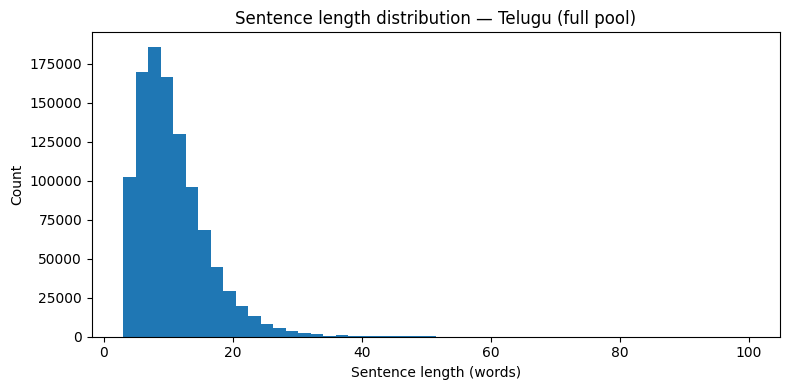

Train pool: 1050000 | Dev: 1000 | Test: 1000
Full   -> mean=10.5  std=5.8  min=3  p25=6  median=9  p75=13  max=100
Dev    -> mean=10.5  std=5.8  min=3  p25=6  median=9  p75=13  max=51
Test   -> mean=10.5  std=5.7  min=3  p25=6  median=9  p75=13  max=52


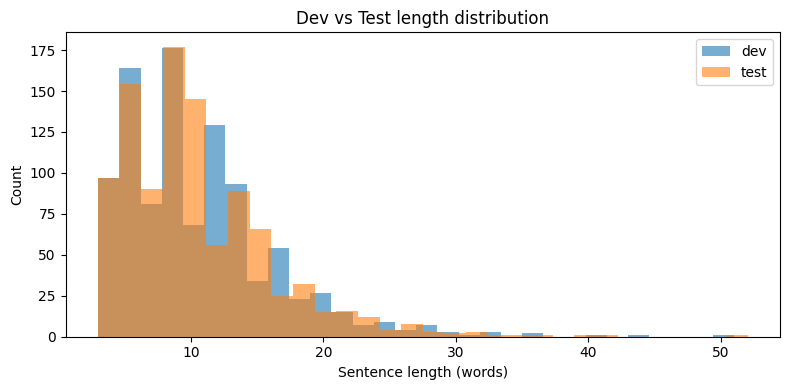

In [6]:
lengths = np.array([word_count(s) for s in all_sentences])

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50)
plt.title(f"Sentence length distribution — {LANGUAGE_NAME} (full pool)")
plt.xlabel("Sentence length (words)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "length_distribution_full.png"))
plt.show()

BIN_EDGES = [0, 5, 10, 15, 20, 25, 30, 40, 50, 70, 100, 1000]

def make_length_bins(lengths, bin_edges=BIN_EDGES):
    return np.digitize(lengths, bin_edges)

bin_ids = make_length_bins(lengths)

def stratified_sample_indices(bin_ids, n_total, exclude=None):
    """
    Samples n_total indices such that the *proportion* taken from each
    length bin matches that bin's share of the overall pool. This is what
    guarantees dev/test aren't dominated by one narrow length range, while
    still reflecting the real distribution (per the assignment hint).
    """
    exclude = exclude or set()
    by_bin = defaultdict(list)
    for idx, b in enumerate(bin_ids):
        if idx in exclude:
            continue
        by_bin[b].append(idx)

    total_pool = sum(len(v) for v in by_bin.values())
    raw_alloc = {b: len(v) / total_pool * n_total for b, v in by_bin.items()}
    alloc = {b: int(math.floor(v)) for b, v in raw_alloc.items()}
    remainder = n_total - sum(alloc.values())

    # largest-remainder method to hit exactly n_total
    fracs = sorted(raw_alloc.items(), key=lambda kv: (kv[1] - math.floor(kv[1])), reverse=True)
    i = 0
    while remainder > 0 and i < len(fracs):
        b = fracs[i][0]
        if alloc[b] < len(by_bin[b]):
            alloc[b] += 1
            remainder -= 1
        i += 1

    selected = []
    for b, count in alloc.items():
        pool = by_bin[b]
        count = min(count, len(pool))
        selected.extend(random.sample(pool, count))
    random.shuffle(selected)
    return set(selected)

dev_idx  = stratified_sample_indices(bin_ids, DEV_SIZE)
test_idx = stratified_sample_indices(bin_ids, TEST_SIZE, exclude=dev_idx)

dev_sentences  = [all_sentences[i] for i in dev_idx]
test_sentences = [all_sentences[i] for i in test_idx]

train_pool_idx = [i for i in range(len(all_sentences)) if i not in dev_idx and i not in test_idx]
train_pool = [all_sentences[i] for i in train_pool_idx]
random.shuffle(train_pool)   # shuffle ONCE so size-prefixes below are nested/comparable

print(f"Train pool: {len(train_pool)} | Dev: {len(dev_sentences)} | Test: {len(test_sentences)}")

# Sanity check: dev/test length distribution should track the full pool,
# not cluster on one length band.
def summarize_lengths(name, sents):
    L = np.array([word_count(s) for s in sents])
    print(f"{name:6s} -> mean={L.mean():.1f}  std={L.std():.1f}  "
          f"min={L.min()}  p25={np.percentile(L,25):.0f}  "
          f"median={np.median(L):.0f}  p75={np.percentile(L,75):.0f}  max={L.max()}")

summarize_lengths("Full", all_sentences)
summarize_lengths("Dev",  dev_sentences)
summarize_lengths("Test", test_sentences)

plt.figure(figsize=(8, 4))
plt.hist([word_count(s) for s in dev_sentences], bins=30, alpha=0.6, label="dev")
plt.hist([word_count(s) for s in test_sentences], bins=30, alpha=0.6, label="test")
plt.legend(); plt.title("Dev vs Test length distribution")
plt.xlabel("Sentence length (words)"); plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "dev_test_length_distribution.png"))
plt.show()

### Cell 6 — Save splits to disk

In [7]:
def save_lines(path, lines):
    with open(path, "w", encoding="utf-8") as f:
        for l in lines:
            f.write(l.replace("\n", " ").strip() + "\n")

save_lines(os.path.join(OUT_DIR, "dev.txt"),  dev_sentences)
save_lines(os.path.join(OUT_DIR, "test.txt"), test_sentences)
save_lines(os.path.join(OUT_DIR, "train_pool_full.txt"), train_pool)

# Nested training subsets (each smaller size is a prefix of the larger ones,
# so size comparisons in Part 3 aren't confounded by different content)
train_subsets = {}
for size in TRAIN_SIZES:
    subset = train_pool[:size]
    train_subsets[size] = subset
    save_lines(os.path.join(OUT_DIR, f"train_{size}.txt"), subset)
    print(f"train_{size}: {len(subset)} sentences saved")

train_100000: 100000 sentences saved
train_300000: 300000 sentences saved
train_500000: 500000 sentences saved
train_1000000: 1000000 sentences saved


### Cell 7 — Tokenizer training functions (BPE & WordPiece)

In [8]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, normalizers, decoders

SPECIAL_TOKENS = ["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"]

def train_bpe(sentences, vocab_size, save_path=None):
    tok = Tokenizer(models.BPE(unk_token="[UNK]"))
    tok.normalizer = normalizers.NFKC()
    tok.pre_tokenizer = pre_tokenizers.Whitespace()
    trainer = trainers.BpeTrainer(
        vocab_size=vocab_size, special_tokens=SPECIAL_TOKENS, min_frequency=2,
    )
    tok.train_from_iterator(sentences, trainer=trainer)
    tok.decoder = decoders.BPEDecoder()
    if save_path:
        tok.save(save_path)
    return tok

def train_wordpiece(sentences, vocab_size, save_path=None):
    tok = Tokenizer(models.WordPiece(unk_token="[UNK]"))
    tok.normalizer = normalizers.NFKC()
    tok.pre_tokenizer = pre_tokenizers.Whitespace()
    trainer = trainers.WordPieceTrainer(
        vocab_size=vocab_size, special_tokens=SPECIAL_TOKENS, min_frequency=2,
    )
    tok.train_from_iterator(sentences, trainer=trainer)
    tok.decoder = decoders.WordPiece()
    if save_path:
        tok.save(save_path)
    return tok

### Cell 8 — Evaluation utilities

In [9]:
def evaluate_tokenizer(tok, sentences):
    total_tokens = total_chars = total_words = unk_count = 0
    unk_id = tok.token_to_id("[UNK]")
    for s in sentences:
        ids = tok.encode(s).ids
        total_tokens += len(ids)
        total_chars  += len(s)
        total_words  += len(s.split())
        unk_count    += sum(1 for i in ids if i == unk_id)
    return {
        "n_sentences": len(sentences),
        "avg_tokens_per_sentence": total_tokens / len(sentences),
        "avg_tokens_per_word": total_tokens / total_words,
        "chars_per_token": total_chars / total_tokens,
        "unk_rate_%": 100 * unk_count / total_tokens,
        "vocab_size": tok.get_vocab_size(),
    }

def save_tokenized(tok, sentences, path):
    with open(path, "w", encoding="utf-8") as f:
        for s in sentences:
            f.write(" ".join(tok.encode(s).tokens) + "\n")

### Cell 9 — PART 3: vary training-data SIZE, vocab fixed

In [10]:
results_size_study = {"bpe": {}, "wordpiece": {}}

for size in TRAIN_SIZES:
    sents = train_subsets[size]
    print(f"\n=== Training size = {size} (vocab={FIXED_VOCAB_FOR_SIZE_STUDY}) ===")

    bpe_tok = train_bpe(sents, FIXED_VOCAB_FOR_SIZE_STUDY,
                         save_path=os.path.join(OUT_DIR, f"bpe_size{size}.json"))
    wp_tok  = train_wordpiece(sents, FIXED_VOCAB_FOR_SIZE_STUDY,
                         save_path=os.path.join(OUT_DIR, f"wp_size{size}.json"))

    results_size_study["bpe"][size] = {
        "dev":  evaluate_tokenizer(bpe_tok, dev_sentences),
        "test": evaluate_tokenizer(bpe_tok, test_sentences),
    }
    results_size_study["wordpiece"][size] = {
        "dev":  evaluate_tokenizer(wp_tok, dev_sentences),
        "test": evaluate_tokenizer(wp_tok, test_sentences),
    }

    save_tokenized(bpe_tok, dev_sentences,  os.path.join(OUT_DIR, f"dev_bpe_size{size}.txt"))
    save_tokenized(bpe_tok, test_sentences, os.path.join(OUT_DIR, f"test_bpe_size{size}.txt"))
    save_tokenized(wp_tok,  dev_sentences,  os.path.join(OUT_DIR, f"dev_wp_size{size}.txt"))
    save_tokenized(wp_tok,  test_sentences, os.path.join(OUT_DIR, f"test_wp_size{size}.txt"))

    print(f"  BPE       dev avg tokens/sentence = "
          f"{results_size_study['bpe'][size]['dev']['avg_tokens_per_sentence']:.2f}")
    print(f"  WordPiece dev avg tokens/sentence = "
          f"{results_size_study['wordpiece'][size]['dev']['avg_tokens_per_sentence']:.2f}")


=== Training size = 100000 (vocab=30000) ===






  BPE       dev avg tokens/sentence = 15.74
  WordPiece dev avg tokens/sentence = 16.09

=== Training size = 300000 (vocab=30000) ===






  BPE       dev avg tokens/sentence = 15.66
  WordPiece dev avg tokens/sentence = 16.04

=== Training size = 500000 (vocab=30000) ===






  BPE       dev avg tokens/sentence = 15.66
  WordPiece dev avg tokens/sentence = 16.03

=== Training size = 1000000 (vocab=30000) ===






  BPE       dev avg tokens/sentence = 15.63
  WordPiece dev avg tokens/sentence = 16.07


### Cell 10 — PART 4: vary VOCAB size, training size fixed

In [11]:
fixed_train_sents = train_subsets[FIXED_TRAIN_FOR_VOCAB_STUDY]
results_vocab_study = {"bpe": {}, "wordpiece": {}}

for vs in VOCAB_SIZES:
    print(f"\n=== Vocab size = {vs} (train_size={FIXED_TRAIN_FOR_VOCAB_STUDY}) ===")

    bpe_tok = train_bpe(fixed_train_sents, vs,
                         save_path=os.path.join(OUT_DIR, f"bpe_vocab{vs}.json"))
    wp_tok  = train_wordpiece(fixed_train_sents, vs,
                         save_path=os.path.join(OUT_DIR, f"wp_vocab{vs}.json"))

    results_vocab_study["bpe"][vs] = {
        "dev":  evaluate_tokenizer(bpe_tok, dev_sentences),
        "test": evaluate_tokenizer(bpe_tok, test_sentences),
    }
    results_vocab_study["wordpiece"][vs] = {
        "dev":  evaluate_tokenizer(wp_tok, dev_sentences),
        "test": evaluate_tokenizer(wp_tok, test_sentences),
    }

    save_tokenized(bpe_tok, dev_sentences,  os.path.join(OUT_DIR, f"dev_bpe_vocab{vs}.txt"))
    save_tokenized(bpe_tok, test_sentences, os.path.join(OUT_DIR, f"test_bpe_vocab{vs}.txt"))
    save_tokenized(wp_tok,  dev_sentences,  os.path.join(OUT_DIR, f"dev_wp_vocab{vs}.txt"))
    save_tokenized(wp_tok,  test_sentences, os.path.join(OUT_DIR, f"test_wp_vocab{vs}.txt"))

    print(f"  BPE       dev avg tokens/sentence = "
          f"{results_vocab_study['bpe'][vs]['dev']['avg_tokens_per_sentence']:.2f}")
    print(f"  WordPiece dev avg tokens/sentence = "
          f"{results_vocab_study['wordpiece'][vs]['dev']['avg_tokens_per_sentence']:.2f}")


=== Vocab size = 20000 (train_size=500000) ===






  BPE       dev avg tokens/sentence = 16.55
  WordPiece dev avg tokens/sentence = 17.10

=== Vocab size = 30000 (train_size=500000) ===






  BPE       dev avg tokens/sentence = 15.66
  WordPiece dev avg tokens/sentence = 16.03

=== Vocab size = 50000 (train_size=500000) ===






  BPE       dev avg tokens/sentence = 14.77
  WordPiece dev avg tokens/sentence = 15.03


### Cell 11 — Tabulate + save results

In [12]:
def flatten_results(results, x_label):
    rows = []
    for algo, per_x in results.items():
        for x, splits in per_x.items():
            for split_name, metrics in splits.items():
                row = {"algorithm": algo, x_label: x, "split": split_name}
                row.update(metrics)
                rows.append(row)
    return pd.DataFrame(rows)

df_size  = flatten_results(results_size_study,  "train_size")
df_vocab = flatten_results(results_vocab_study, "vocab_size")

df_size.to_csv(os.path.join(OUT_DIR, "results_train_size_study.csv"), index=False)
df_vocab.to_csv(os.path.join(OUT_DIR, "results_vocab_size_study.csv"), index=False)

with open(os.path.join(OUT_DIR, "results_all.json"), "w") as f:
    json.dump({"size_study": results_size_study, "vocab_study": results_vocab_study}, f, indent=2)

print("\n=== Training-size study (test split) ===")
print(df_size[df_size.split == "test"].sort_values(["algorithm", "train_size"])
      .to_string(index=False))

print("\n=== Vocab-size study (test split) ===")
print(df_vocab[df_vocab.split == "test"].sort_values(["algorithm", "vocab_size"])
      .to_string(index=False))


=== Training-size study (test split) ===
algorithm  train_size split  n_sentences  avg_tokens_per_sentence  avg_tokens_per_word  chars_per_token  unk_rate_%  vocab_size
      bpe      100000  test         1000                   15.842             1.514242         5.171885         0.0       30000
      bpe      300000  test         1000                   15.809             1.511088         5.182681         0.0       30000
      bpe      500000  test         1000                   15.831             1.513191         5.175478         0.0       30000
      bpe     1000000  test         1000                   15.816             1.511757         5.180387         0.0       30000
wordpiece      100000  test         1000                   16.298             1.557828         5.027181         0.0       30000
wordpiece      300000  test         1000                   16.240             1.552284         5.045135         0.0       30000
wordpiece      500000  test         1000                   16.

### Cell 12 — Plots

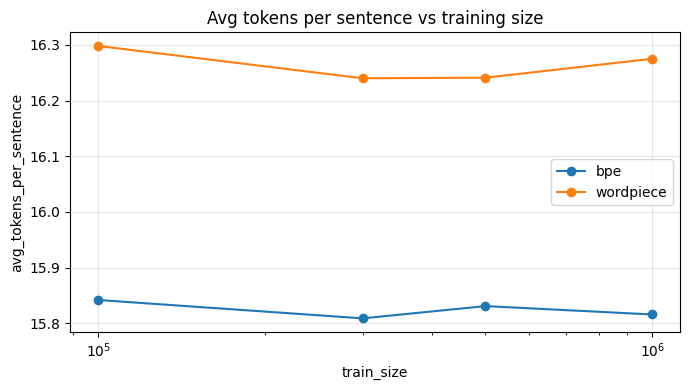

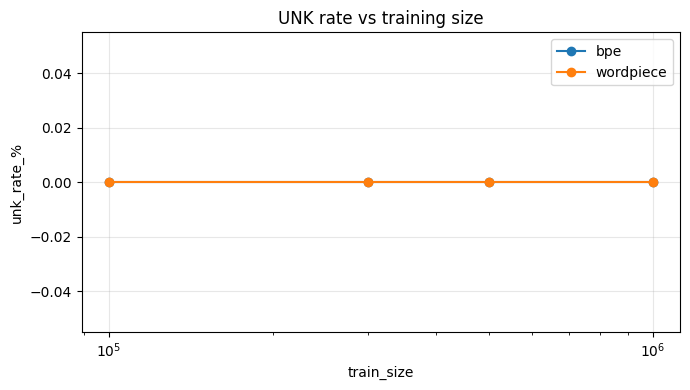

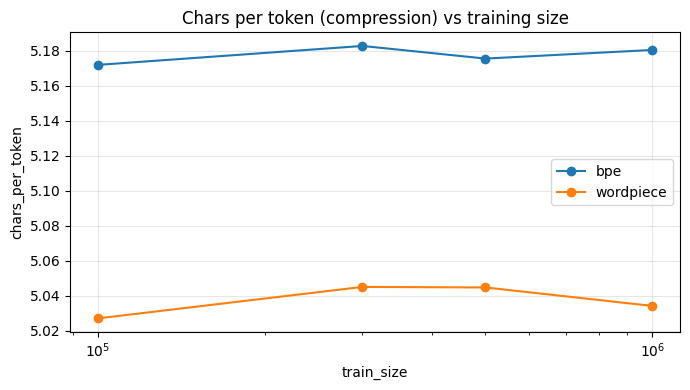

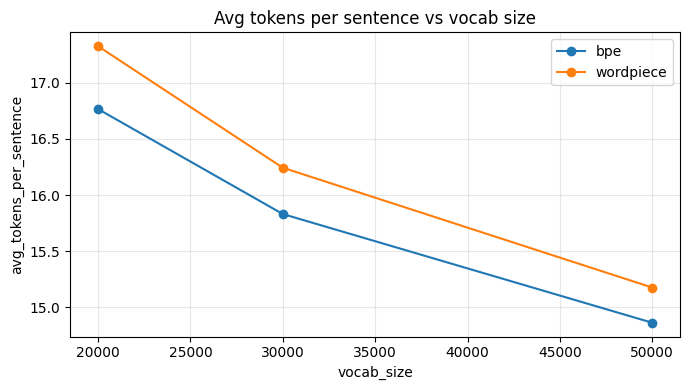

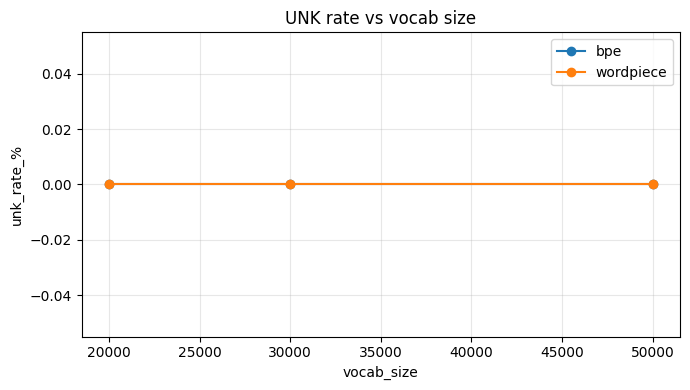

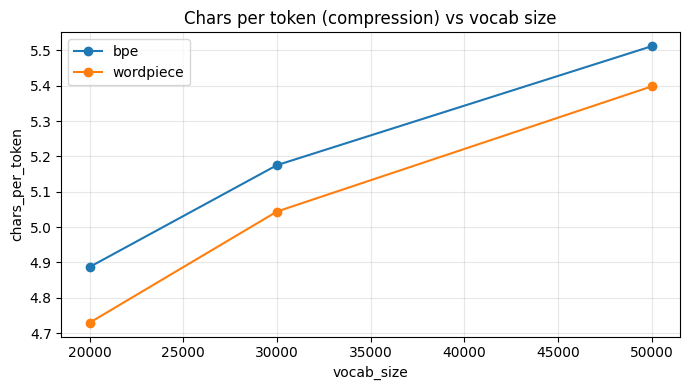

In [13]:
def plot_metric_vs_x(df, x_col, metric, title, logx=False):
    plt.figure(figsize=(7, 4))
    for algo in df["algorithm"].unique():
        sub = df[(df.algorithm == algo) & (df.split == "test")].sort_values(x_col)
        plt.plot(sub[x_col], sub[metric], marker="o", label=algo)
    if logx:
        plt.xscale("log")
    plt.xlabel(x_col); plt.ylabel(metric); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    fname = title.lower().replace(" ", "_").replace("/", "_") + ".png"
    plt.savefig(os.path.join(OUT_DIR, fname))
    plt.show()

plot_metric_vs_x(df_size,  "train_size", "avg_tokens_per_sentence",
                  "Avg tokens per sentence vs training size", logx=True)
plot_metric_vs_x(df_size,  "train_size", "unk_rate_%",
                  "UNK rate vs training size", logx=True)
plot_metric_vs_x(df_size,  "train_size", "chars_per_token",
                  "Chars per token (compression) vs training size", logx=True)

plot_metric_vs_x(df_vocab, "vocab_size", "avg_tokens_per_sentence",
                  "Avg tokens per sentence vs vocab size")
plot_metric_vs_x(df_vocab, "vocab_size", "unk_rate_%",
                  "UNK rate vs vocab size")
plot_metric_vs_x(df_vocab, "vocab_size", "chars_per_token",
                  "Chars per token (compression) vs vocab size")

### Cell 13 — Qualitative comparison: same sentences, different tokenizers

In [14]:
sample_sentences = dev_sentences[:5]

def show_tokenizations(sentences, tok, name):
    print(f"\n--- {name} ---")
    for s in sentences:
        print(f"SRC: {s}")
        print(f"TOK: {tok.encode(s).tokens}\n")

best_bpe = train_bpe(train_subsets[FIXED_TRAIN_FOR_VOCAB_STUDY], 30_000)
best_wp  = train_wordpiece(train_subsets[FIXED_TRAIN_FOR_VOCAB_STUDY], 30_000)

show_tokenizations(sample_sentences, best_bpe, "BPE (train=500k, vocab=30k)")
show_tokenizations(sample_sentences, best_wp,  "WordPiece (train=500k, vocab=30k)")

print(f"\nAll outputs (splits, tokenizer files, tokenized dev/test, CSVs, plots) "
      f"saved under: {OUT_DIR}")








--- BPE (train=500k, vocab=30k) ---
SRC: తాజాగా ఇజిన్‌ అనే కౌంటీలో కరోనా డెల్టా వేరియంట్‌ ప్రబలింది.
TOK: ['తాజాగా', 'ఇ', 'జిన్\u200c', 'అనే', 'కౌంటీ', 'లో', 'కరోనా', 'డెల్టా', 'వేరియంట్\u200c', 'ప్ర', 'బలి', 'ంది', '.']

SRC: నాలుగువేల కోట్ల విలువైన పనులను ‘ట్రాన్స్‌ట్రాయ్’కి అప్పగించారు.
TOK: ['నాలుగు', 'వేల', 'కోట్ల', 'విలువైన', 'పనులను', '‘', 'ట్రాన్స్\u200c', 'ట్రాయ్', '’', 'కి', 'అప్పగించారు', '.']

SRC: గెట్‌ రెడీ. . మూడొంతుల ఓట్లు మనకే రావాలె
TOK: ['గె', 'ట్\u200c', 'రెడీ', '.', '.', 'మూ', 'డొ', 'ం', 'తుల', 'ఓట్లు', 'మన', 'కే', 'రావ', 'ాలె']

SRC: ఆయా ప్రాంతాల స్వభావం, సామాజిక పరిస్థితులకు అనుగుణంగా ప్రభుత్వ శాఖల విభాగాలు ఏర్పాటు చేయాలన్నారు.
TOK: ['ఆయా', 'ప్రాంతాల', 'స్వభావం', ',', 'సామాజిక', 'పరిస్థితులకు', 'అనుగుణంగా', 'ప్రభుత్వ', 'శాఖల', 'విభాగాలు', 'ఏర్పాటు', 'చేయాలన్నారు', '.']

SRC: మరియు అన్ని సమస్యలను పరిష్కరించటానికి, చాలా, చాలా ఉంటుంది.
TOK: ['మరియు', 'అన్ని', 'సమస్యలను', 'పరిష్కరి', 'ంచటానికి', ',', 'చాలా', ',', 'చాలా', 'ఉంటుంది', '.']


--- WordPiece (train=